<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Time Series EDA Lab

---

This lab covers the exploratory toolkit you need **before** fitting any time series model. It walks through: 

- Loading and indexing a real-world time series
- Visualizing trend by resampling / rolling smoothing
- Testing for stationarity with the Augmented Dickey-Fuller (ADF) test
- Diagnosing the series using ACF and PACF plots

## About the Data

`residents.csv` contains a **quarterly resident population count**, in thousands, from **April 1971 to April 1993** (89 quarters):

| Column | Description |
|---|---|
| `date` | Quarter (month-year, e.g. `04-1971`) |
| `residents` | Resident population that quarter, in thousands |

We're going to hold the **final 8 quarters (1991–1993)** out completely. Everything in this EDA lab uses only the first **81 quarters (1971–1990)**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('fivethirtyeight')

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

## Part 1 - Load and Set Aside the Holdout 

### 1. Load `residents.csv`, parse `date` as a datetime (format is `MM-YYYY`), and set it as the index.

In [6]:
# YOUR CODE HERE
df = pd.read_csv('./data/residents.csv')
df['date'] = pd.to_datetime(df['date'], format='%m-%Y')
df.set_index('date', inplace = True)
df.head()

,residents
date,
1971-04-01,13067.3
1971-07-01,13130.5
1971-10-01,13198.4
1972-01-01,13254.2
1972-04-01,13303.7


### 2. Set aside the final 8 quarters (1991–1993) as `holdout_df`. Keep the remaining 81 quarters (1971–1990) as `df_eda`.

In [10]:
# YOUR CODE HERE
holdout_df = df.iloc[-8:]
df_eda = df.iloc[:-8]

print(f'Holdlout {holdout_df.shape} , EDA {df_eda.shape}')

Holdlout (8, 1) , EDA (81, 1)


### 3. Plot the raw `residents` series. What do you notice about the overall trend? Does the quarter-to-quarter spread look roughly constant, or does it change over time?

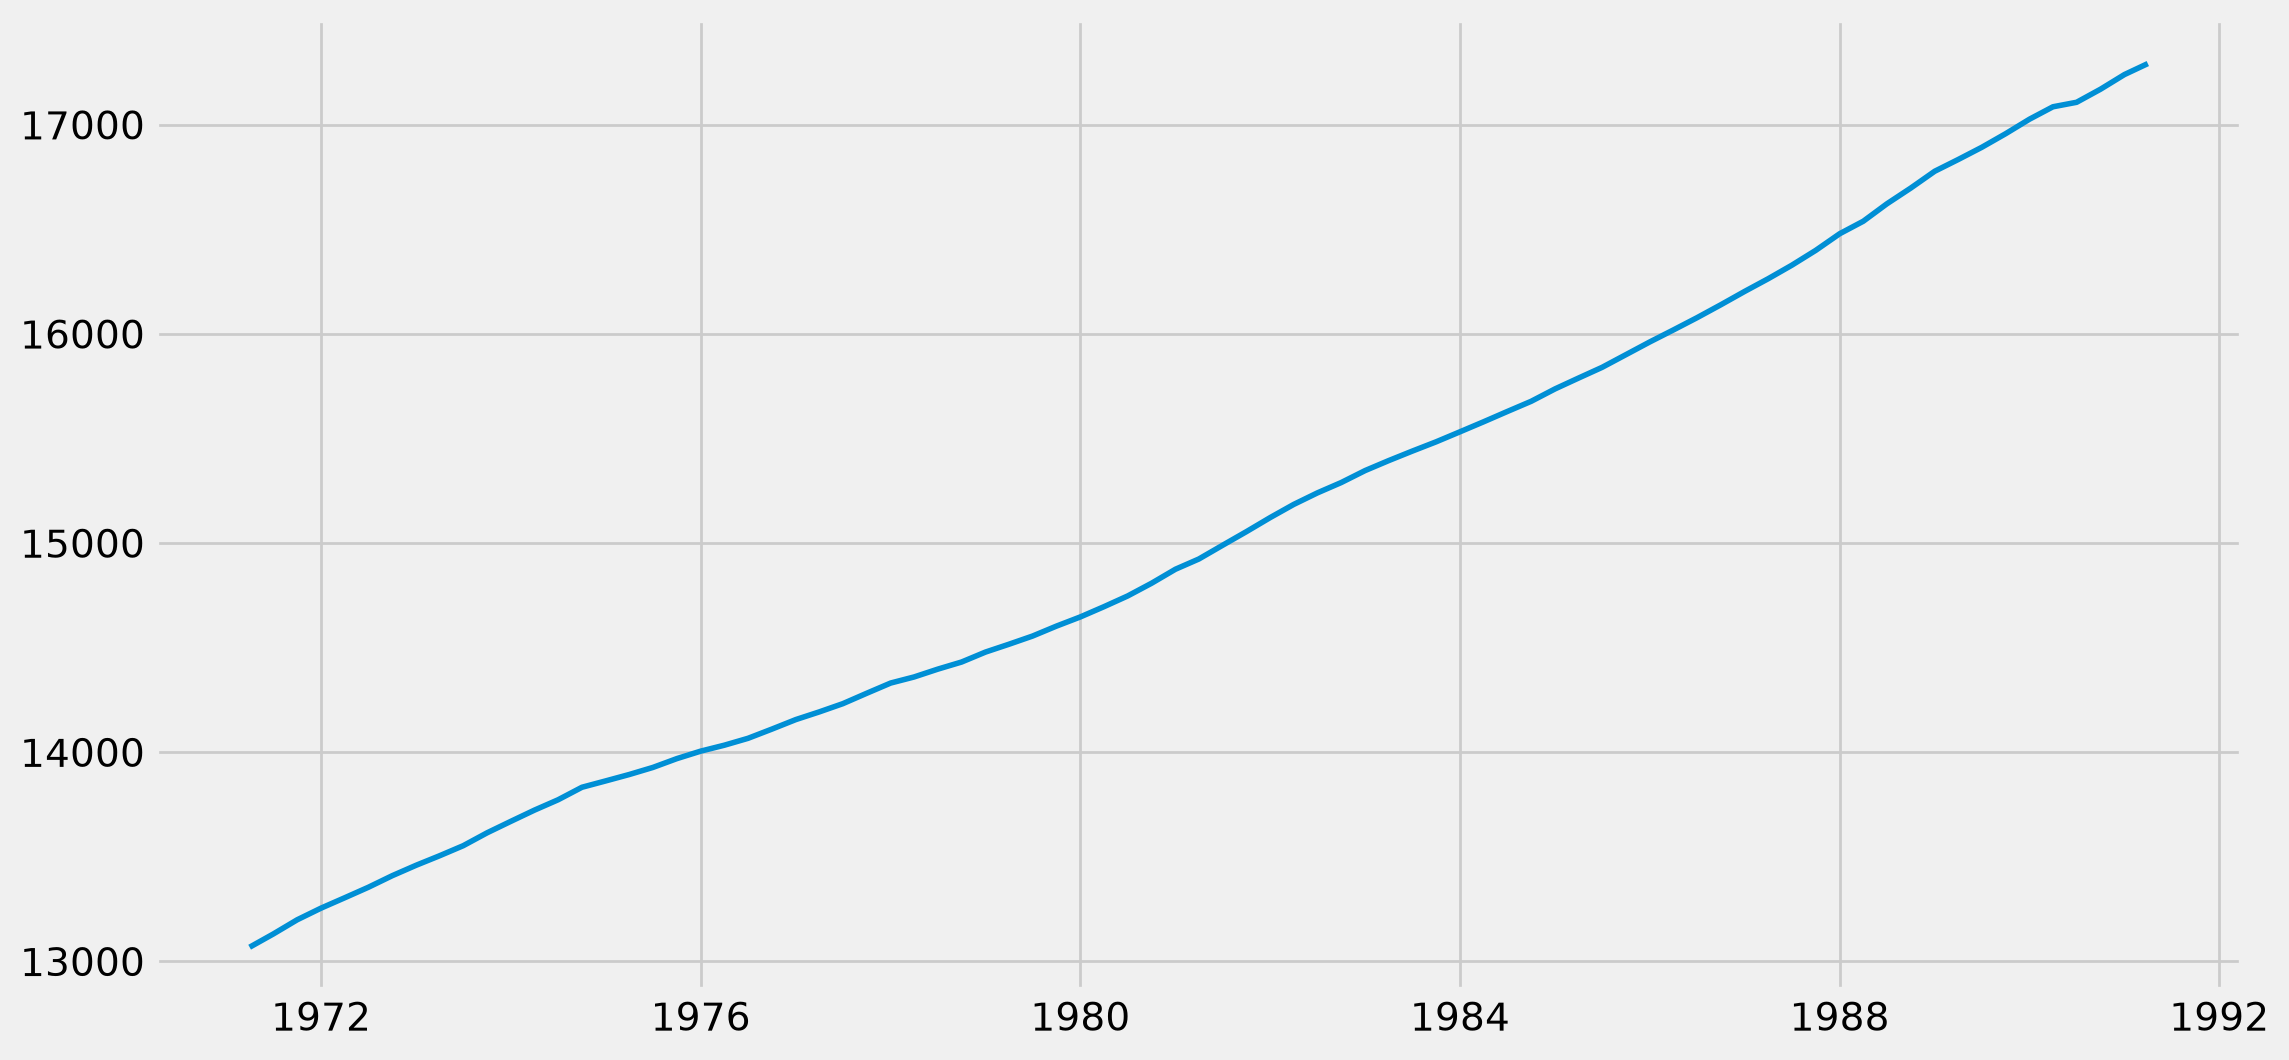

In [17]:
# YOUR CODE HERE
plt.figure(figsize=(12, 6))
plt.plot(df_eda.index, df_eda['residents'], linewidth=2)
plt.show()

# The overall trend is steadily increasing upwards over time.
# The quarter-to-quarter spread is roughly constant (it doesn't widen as the trend goes up).

## Part 2 - Seasonal Decomposition

A time series can be split into three components: **trend**, **seasonal**, and **residual**.

### 4. Decompose `residents` using `seasonal_decompose` (`period=4` since this is quarterly data). Plot the trend, seasonal, and residual components.

<Figure size 1200x800 with 0 Axes>

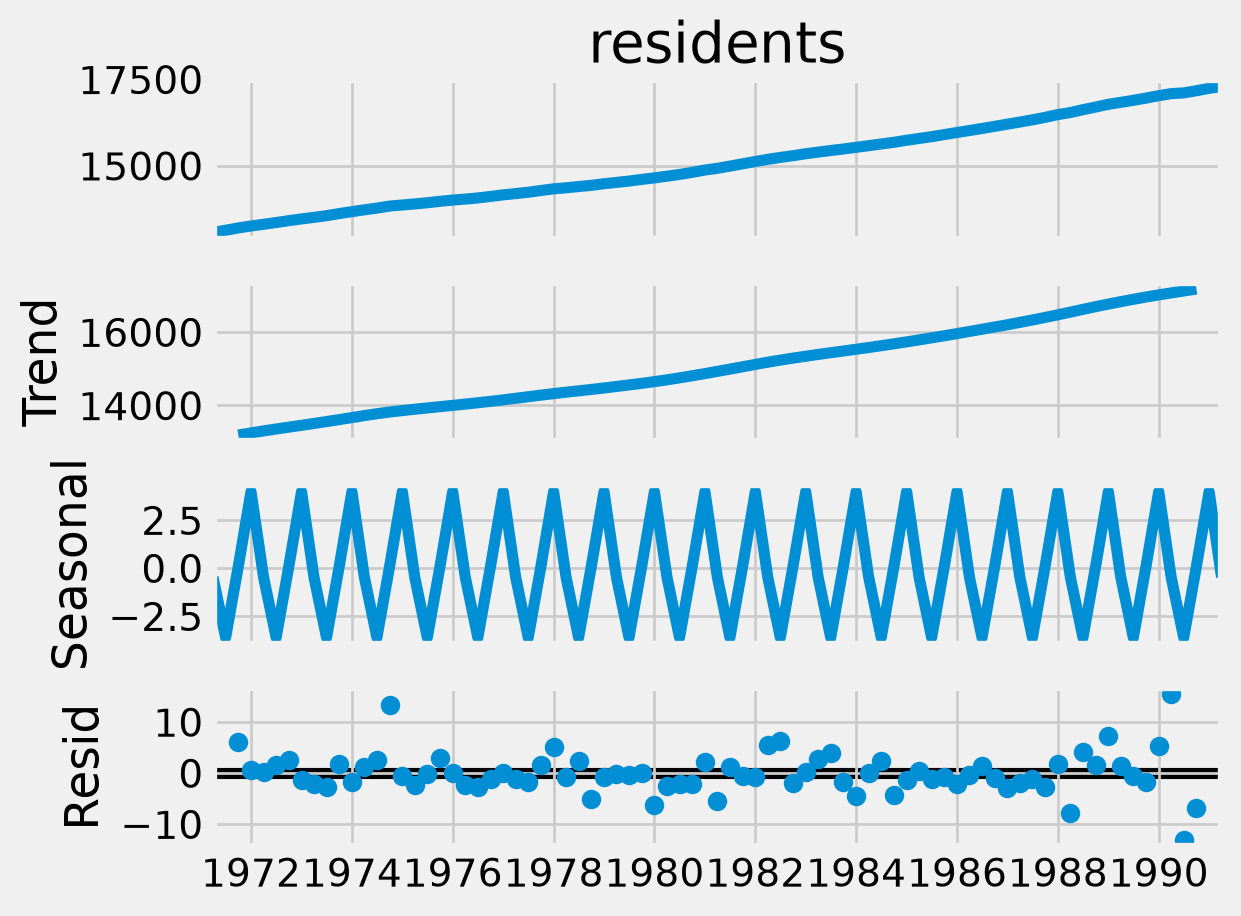

In [21]:
# YOUR CODE HERE
decomp = seasonal_decompose(df_eda['residents'], period=4)

plt.figure(figsize=(12, 8))
decomp.plot()
plt.show()

## Part 3 - Visualizing Trend with Rolling Mean and Resampling.

With quarterly data, a 4-quarter (1-year) rolling window is the suitable choice, as it averages away any seasonal fluctuations and leaves just the trend.

### 5. Compute and plot a 4-quarter rolling mean of `residents`, overlaid on the raw series.

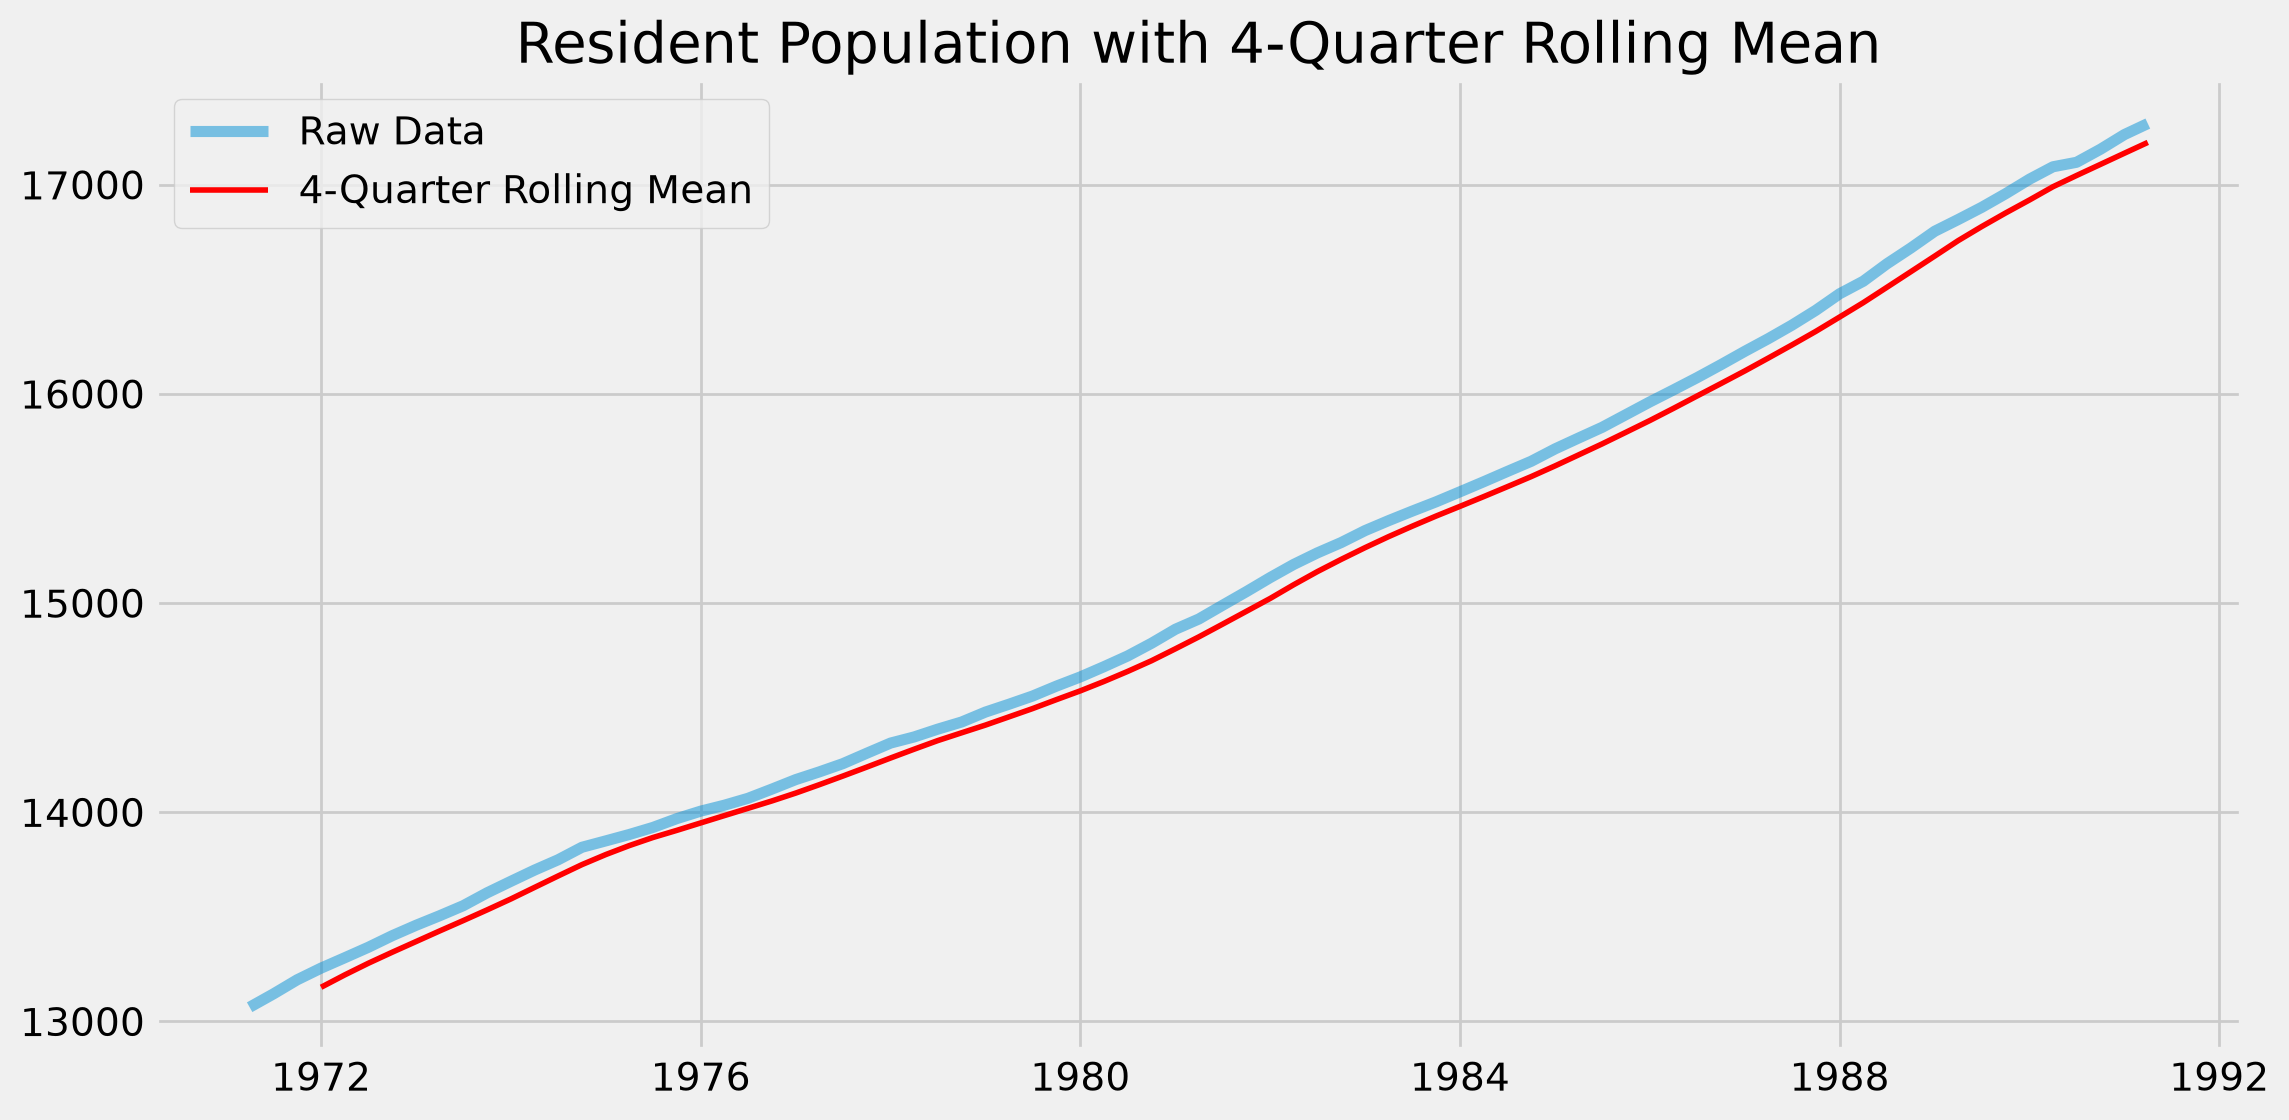

In [23]:
# YOUR CODE HERE
plt.figure(figsize=(12, 6))

plt.plot(df_eda.index, df_eda['residents'], label='Raw Data', alpha=0.5)

# Plot the 4-quarter rolling mean on top
plt.plot(df_eda.index, df_eda['residents'].rolling(window=4).mean(), 
         color='red', linewidth=2, label='4-Quarter Rolling Mean')

plt.title('Resident Population with 4-Quarter Rolling Mean')
plt.legend()
plt.show()

### 6. Plot a 4-quarter rolling standard deviation. Is the spread of fluctuations roughly stable over time, or does it change?

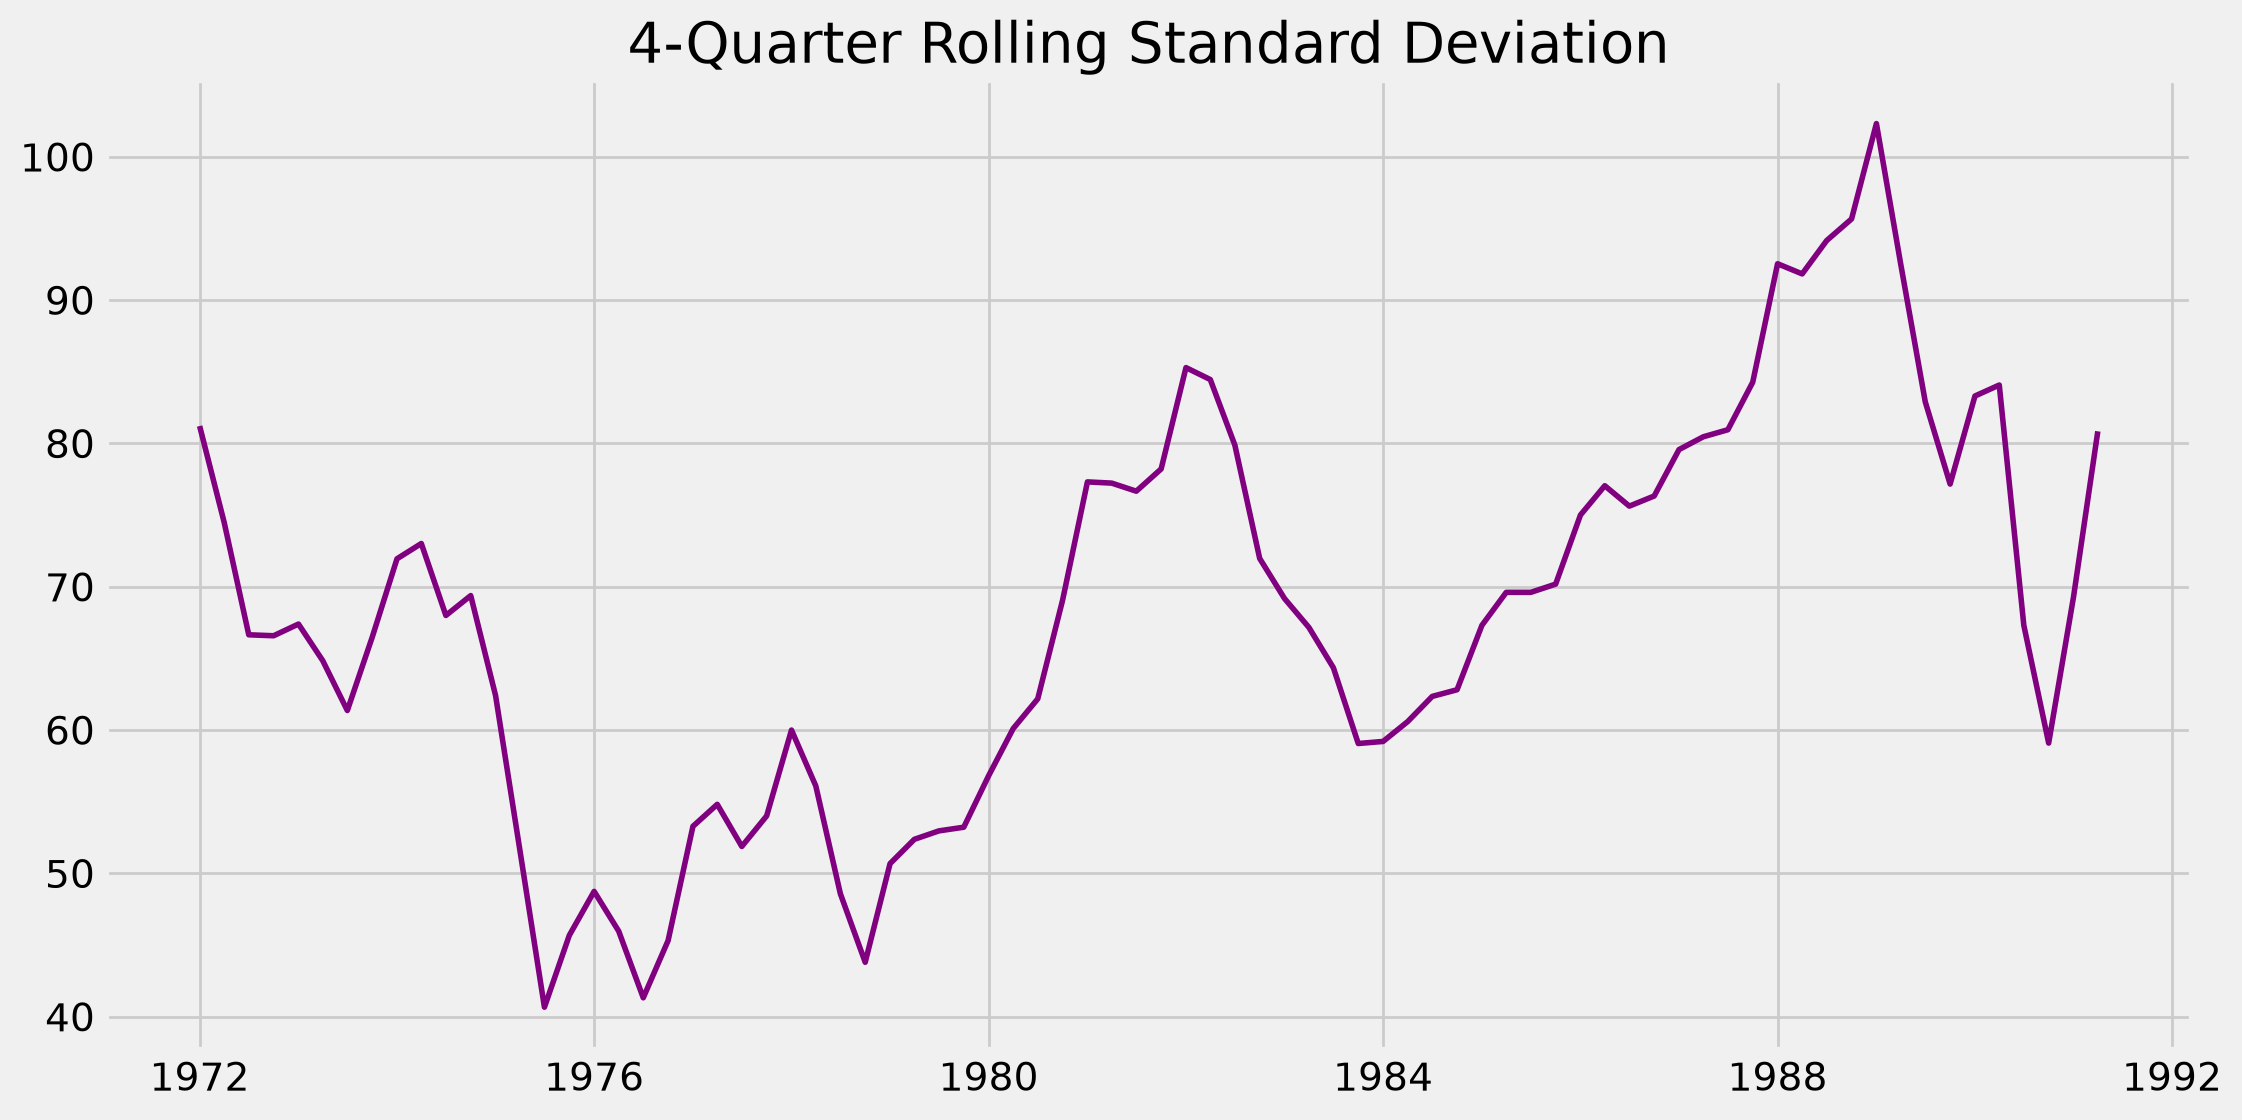

In [24]:
# YOUR CODE HERE
plt.figure(figsize=(12, 6))
plt.plot(df_eda.index, df_eda['residents'].rolling(window=4).std(), color='purple', linewidth=2)
plt.title('4-Quarter Rolling Standard Deviation')
plt.show()

#The spread of fluctuations is roughly stable over time. 
#It fluctuates a bit but doesn't show a clear expanding pattern as the overall population grows.

## Part 4 - Stationarity and the ADF Test

A stationary series has a constant mean, variance, and autocorrelation structure over time *(most classical forecasting models assume this)*. We test for it with the **Augmented Dickey-Fuller (ADF) test**:

- **Null hypothesis (H0):** the series has a unit root (i.e. it is *non-stationary*).
- If the p-value is small (typically ≤ 0.05), we reject H0 and conclude the series **is** *stationary*.

### 7. Write an `adf_test()` helper function that runs `adfuller()` and prints the test statistic, p-value, and a plain-English conclusion.

In [25]:
def adf_test(series):
    """
    Pass in a time series, and prints an ADF report.
    """
    # YOUR CODE HERE
    series = series.dropna()
    result = adfuller(series)
    
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    
    if result[1] <= 0.05:
        print("Rejected the nulls. The series is stationary.")
    else:
        print("Fail to reject the nulls. The series is non-stationary.")

### 8. Run `adf_test()` on the raw `residents` series. Then apply `.diff()` and run it again. Is one difference enough?

In [26]:
# YOUR CODE HERE
adf_test(df_eda['residents']) , adf_test(df_eda['residents'].diff())

ADF Statistic: 1.8104
p-value: 0.9984
Fail to reject the nulls. The series is non-stationary.
ADF Statistic: -2.5056
p-value: 0.1141
Fail to reject the nulls. The series is non-stationary.


(None, None)

### 9. If the first difference wasn't enough, try a second difference (`.diff().diff()`). Is it stationary now? 
*This will be your `d` term in the modeling stage*.

In [27]:
# YOUR CODE HERE
adf_test(df_eda['residents'].diff().diff())

ADF Statistic: -3.1483
p-value: 0.0232
Rejected the nulls. The series is stationary.


## Part 5 - Autocorrelation and Seasonality

ACF and PACF plots show how correlated a series is with its own past values at different lags. We look at these on the **differenced** series, with the trend removed, any repeating seasonal correlation stands out clearly instead of being buried under the trend's slow decay.

### 10. Plot the ACF and PACF of the series out to at least 20 lags.

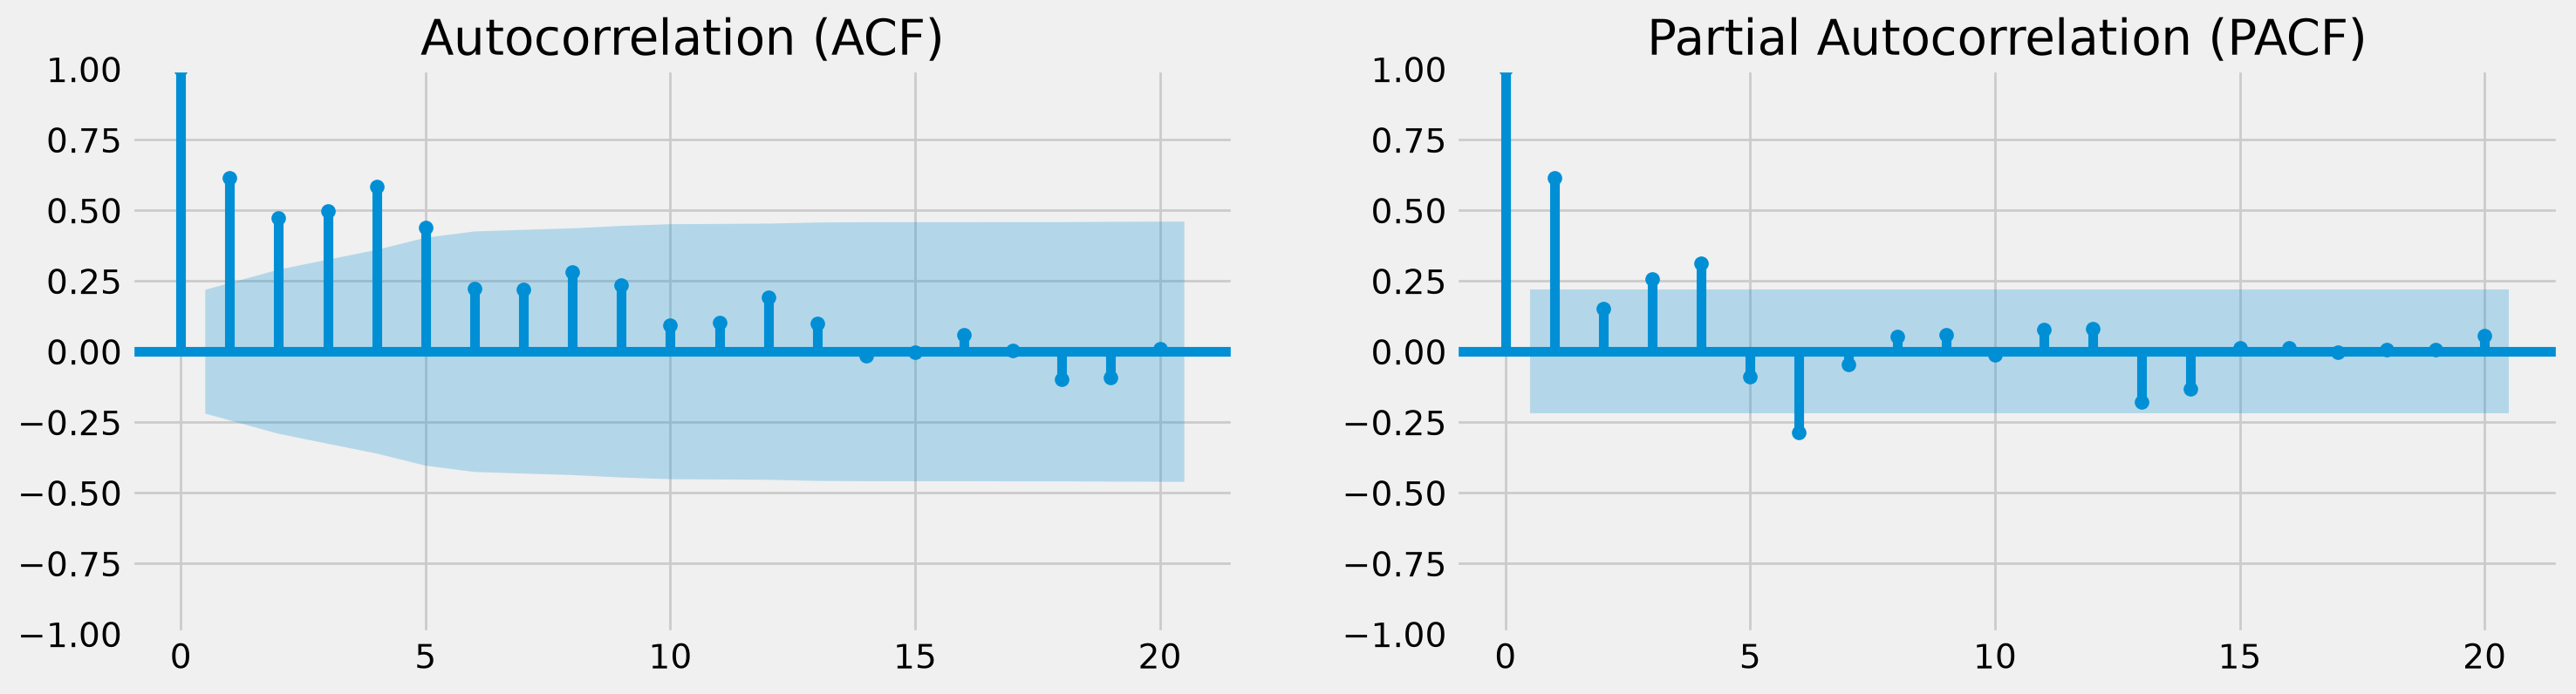

In [28]:
# YOUR CODE HERE
diff_series = df_eda['residents'].diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(diff_series, lags=20, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')
plot_pacf(diff_series, lags=20, ax=axes[1])
axes[1].set_title('Partial Autocorrelation (PACF)')
plt.show()

### 11. Look closely at the ACF plot. At which lag do you see the strongest spike? What does that tell you about the data?

the strongest absolute spike in the ACF plot is actually at lag 1, followed closely by a distinct peak at lag 4. Here is what this tells us about the data:

- The spike at lag 1: Indicates a strong short-term correlation; the population count in a given quarter is heavily dependent on the count from the immediately preceding quarter.

- The peak at lag 4: Because this is quarterly data, the prominent spike at lag 4 confirms there is annual seasonality. The data is highly correlated with the same quarter from exactly one year ago.